# Khám Phá Dữ Liệu Chuyên Sâu (Advanced Exploratory Data Analysis - EDA)

1. **Kiểm tra tính toàn vẹn của dữ liệu (Data Integrity Check):** Phát hiện các file hỏng, file rỗng, định dạng không đồng nhất.
2. **Phân tích siêu dữ liệu (Metadata & Dimension Analysis):** Phân tích sự phân tán của độ phân giải (Resolution), tỷ lệ khung hình (Aspect Ratio), nhằm đưa ra chiến lược `Resize` tối ưu thay vì chọn kích thước ngẫu nhiên.
3. **Phân tích cường độ điểm ảnh (Pixel Intensity & Color Space):** Khám phá phổ cường độ sáng (Histogram), độ tương phản trung bình, để ra quyết định về các bước tiền xử lý như CLAHE, Normalization, hay Grayscale conversion.
4. **Phân bố nhãn & Mất cân bằng dữ liệu (Class Imbalance):** Đánh giá mức độ lệch của các lớp để lựa chọn loss function (như Focal Loss, Weighted Cross Entropy) hoặc kỹ thuật Augmentation phù hợp.
5. **Trực quan hóa cấu trúc không gian (Spatial Feature / Mean Image Analysis):** Tính toán và trực quan hóa "Ảnh trung bình" (Mean Image) của từng lớp để phát hiện các mẫu không gian (Spatial Patterns) phân biệt giữa các loại khối u.
6. **Phân tích Outlier (Outlier Detection):** Tìm các ảnh có cường độ hoặc kích thước bất thường có thể gây nhiễu trong quá trình huấn luyện.


In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm
import warnings
from concurrent.futures import ThreadPoolExecutor

warnings.filterwarnings('ignore')

# Cấu hình phong cách biểu đồ chuẩn chuyên nghiệp
sns.set_theme(style='whitegrid', context='notebook', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12


In [2]:
# Khai báo đường dẫn và hằng số
DATA_DIR = '../data/Training'
CLASSES = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
print(f"Các nhãn được phát hiện: {CLASSES}")


Các nhãn được phát hiện: ['glioma', 'meningioma', 'notumor', 'pituitary']


## 1. Trích xuất Siêu dữ liệu & Kiểm tra tính toàn vẹn (Data Integrity)
Thay vì load ảnh liên tục trong quá trình vẽ biểu đồ, best practice là tạo một Pandas DataFrame chứa metadata của toàn bộ tập dữ liệu. Điều này giúp thao tác phân tích sau này nhanh gọn và sử dụng bộ nhớ hiệu quả.


In [ ]:
def extract_metadata(filepath):
    try:
        # Sử dụng PIL để mở nhanh chóng chỉ lấy metadata, không load toàn bộ array
        with Image.open(filepath) as img:
            width, height = img.size
            mode = img.mode
            format_ = img.format
        file_size = os.path.getsize(filepath) / 1024.0 # KB
        return {
            'filepath': filepath,
            'filename': os.path.basename(filepath),
            'class': os.path.basename(os.path.dirname(filepath)),
            'width': width,
            'height': height,
            'aspect_ratio': width / height,
            'mode': mode,
            'format': format_,
            'size_kb': file_size,
            'is_corrupt': False
        }
    except Exception as e:
        return {
            'filepath': filepath,
            'filename': os.path.basename(filepath),
            'class': os.path.basename(os.path.dirname(filepath)),
            'is_corrupt': True,
            'error': str(e)
        }

# Quét toàn bộ đường dẫn ảnh
all_filepaths = []
for cls in CLASSES:
    cls_dir = os.path.join(DATA_DIR, cls)
    for root, _, files in os.walk(cls_dir):
        for file in files:
            if not file.startswith('.'):
                all_filepaths.append(os.path.join(root, file))

# Trích xuất đa luồng để tiết kiệm thời gian
metadata_list = []
with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    metadata_list = list(tqdm(executor.map(extract_metadata, all_filepaths), total=len(all_filepaths), desc='Extracting Metadata'))

df_meta = pd.DataFrame(metadata_list)

# Báo cáo các file lỗi
corrupted = df_meta[df_meta['is_corrupt'] == True]
print(f"Tổng số ảnh: {len(df_meta)}")
print(f"Số ảnh bị lỗi (Corrupt): {len(corrupted)}")
if len(corrupted) > 0:
    display(corrupted)
else:
    print("Không có ảnh nào bị lỗi.")
    
display(df_meta.head())


Extracting Metadata:   0%|          | 0/5600 [00:00<?, ?it/s]

Tổng số ảnh: 5600
Số ảnh bị lỗi (Corrupt): 0
Tuyệt vời! Không có ảnh nào bị lỗi.


,filepath,filename,class,width,height,aspect_ratio,mode,format,size_kb,is_corrupt
0,../data/Training\glioma\Tr-gl_1.jpg,Tr-gl_1.jpg,glioma,512,512,1.0,L,JPEG,20.402344,False
1,../data/Training\glioma\Tr-gl_10.jpg,Tr-gl_10.jpg,glioma,512,512,1.0,L,JPEG,25.835938,False
2,../data/Training\glioma\Tr-gl_100.jpg,Tr-gl_100.jpg,glioma,512,512,1.0,L,JPEG,19.677734,False
3,../data/Training\glioma\Tr-gl_1000.jpg,Tr-gl_1000.jpg,glioma,512,512,1.0,L,JPEG,24.308594,False
4,../data/Training\glioma\Tr-gl_1001.jpg,Tr-gl_1001.jpg,glioma,512,512,1.0,L,JPEG,14.410156,False


## 2. Phân bố nhãn (Class Distribution & Imbalance)
Đánh giá mức độ cân bằng của tập dữ liệu.


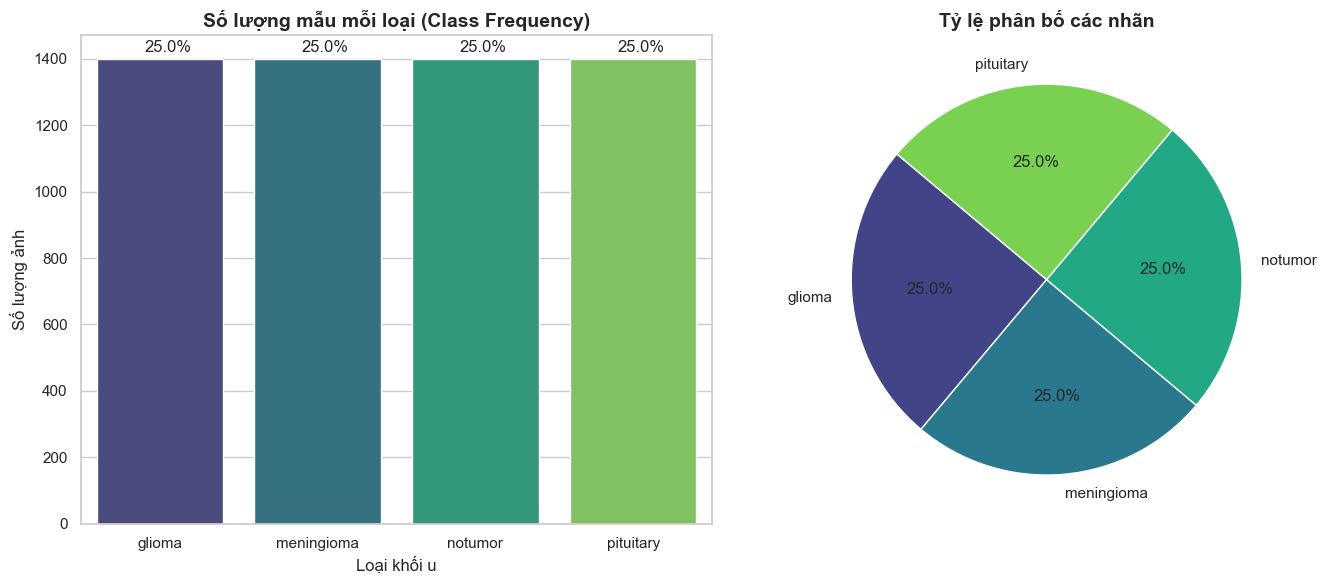

Nhận xét: Tỷ lệ mất cân bằng (Max/Min) là 1.00.
=> TỐT: Tập dữ liệu khá cân bằng. Không cần áp dụng các biện pháp xử lý mất cân bằng quá phức tạp.


In [4]:
plt.figure(figsize=(14, 6))

# Biểu đồ đếm
plt.subplot(1, 2, 1)
ax = sns.countplot(data=df_meta, x='class', palette='viridis', order=df_meta['class'].value_counts().index)
plt.title('Số lượng mẫu mỗi loại (Class Frequency)')
plt.ylabel('Số lượng ảnh')
plt.xlabel('Loại khối u')

# Ghi chú phần trăm
total = len(df_meta)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + 20
    ax.annotate(percentage, (x, y), size=12)

# Biểu đồ tròn
plt.subplot(1, 2, 2)
class_counts = df_meta['class'].value_counts()
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(CLASSES)))
plt.title('Tỷ lệ phân bố các nhãn')

plt.tight_layout()
plt.show()

# Nhận xét chuyên sâu
min_class = class_counts.idxmin()
max_class = class_counts.idxmax()
imbalance_ratio = class_counts[max_class] / class_counts[min_class]
print(f"Nhận xét: Tỷ lệ mất cân bằng (Max/Min) là {imbalance_ratio:.2f}.")
if imbalance_ratio > 1.5:
    print("=> CẢNH BÁO: Tập dữ liệu bị mất cân bằng đáng kể. Đề xuất: Cân nhắc sử dụng Class Weights, Oversampling (SMOTE/Augmentation cho lớp thiểu số), hoặc Focal Loss trong quá trình huấn luyện.")
else:
    print("=> TỐT: Tập dữ liệu khá cân bằng. Không cần áp dụng các biện pháp xử lý mất cân bằng quá phức tạp.")


## 3. Phân tích Kích thước và Tỷ lệ khung hình (Dimensions & Aspect Ratio)
Kích thước ảnh đa dạng là một đặc trưng của dữ liệu y tế thực tế. Bước này sẽ chỉ đạo chính xác ta nên resize ảnh về độ phân giải nào (ví dụ 224x224, 256x256 hay một khung hình chữ nhật).


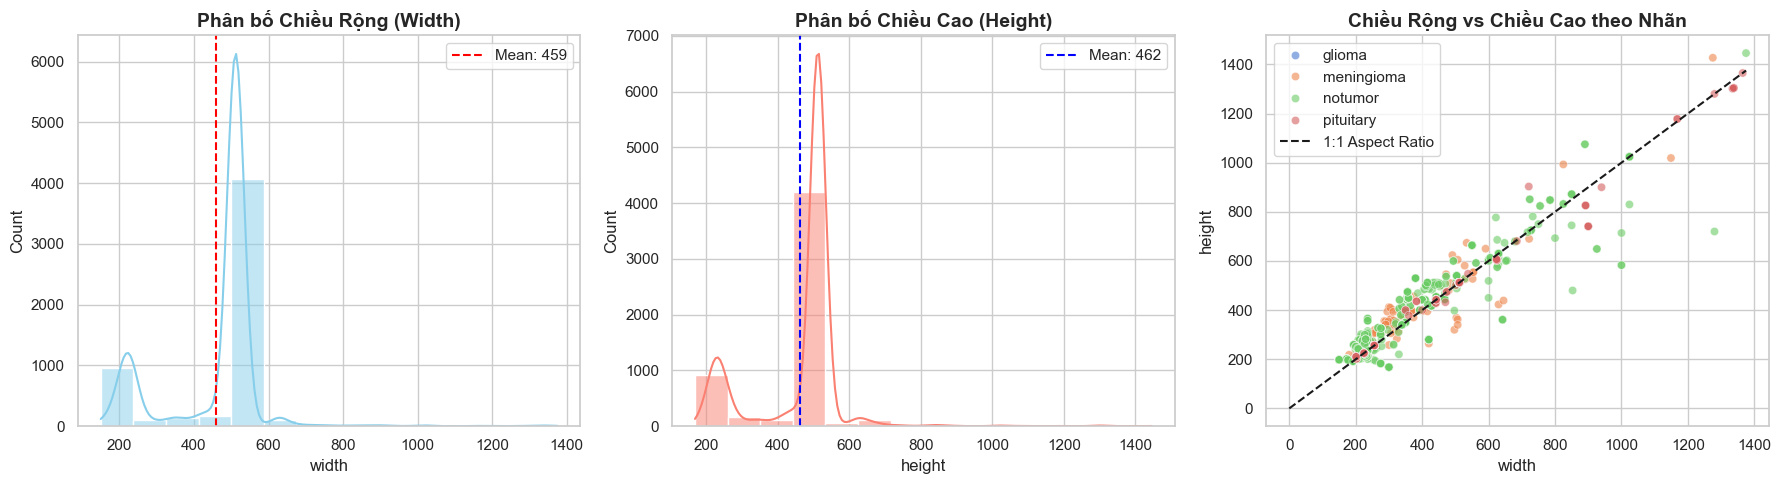

Thống kê kích thước:


,count,mean,std,min,25%,50%,75%,max
width,5600.0,458.513750,129.619399,150.000000,512.0,512.0,512.0,1375.000000
height,5600.0,462.262857,123.617483,168.000000,512.0,512.0,512.0,1446.000000
aspect_ratio,5600.0,0.988435,0.079300,0.644809,1.0,1.0,1.0,1.785714


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Phân bố Width
sns.histplot(df_meta['width'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Phân bố Chiều Rộng (Width)')
axes[0].axvline(df_meta['width'].mean(), color='red', linestyle='--', label=f"Mean: {df_meta['width'].mean():.0f}")
axes[0].legend()

# 2. Phân bố Height
sns.histplot(df_meta['height'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Phân bố Chiều Cao (Height)')
axes[1].axvline(df_meta['height'].mean(), color='blue', linestyle='--', label=f"Mean: {df_meta['height'].mean():.0f}")
axes[1].legend()

# 3. Scatter plot Width vs Height
sns.scatterplot(data=df_meta, x='width', y='height', hue='class', alpha=0.6, ax=axes[2])
axes[2].set_title('Chiều Rộng vs Chiều Cao theo Nhãn')
axes[2].plot([0, df_meta['width'].max()], [0, df_meta['width'].max()], 'k--', label='1:1 Aspect Ratio')
axes[2].legend()

plt.tight_layout()
plt.show()

print("Thống kê kích thước:")
display(df_meta[['width', 'height', 'aspect_ratio']].describe().T)


### Đề xuất chiến lược Resize (Senior Recommendation):
Dựa vào Median và Mean của chiều rộng/chiều cao, cũng như tỷ lệ aspect ratio (phần lớn xấp xỉ 1.0 tức là ảnh vuông), chúng ta nên áp dụng **Resize kết hợp Padding (Letterbox Resize)** thay vì bóp méo (Distortion Resize) hoặc crop mất phần rìa não. Kích thước mục tiêu phổ biến như `(224, 224)` hoặc `(256, 256)` là hợp lý nhất.


## 4. Phân tích cường độ điểm ảnh (Pixel Intensity Distribution)
Trong ảnh MRI, độ sáng (intensity) biểu diễn mật độ mô. Các ảnh có thể bị tối hoặc sáng quá mức do đến từ các nguồn/máy quét khác nhau. Ta lấy mẫu để kiểm tra.


Computing Pixel Stats:   0%|          | 0/500 [00:00<?, ?it/s]

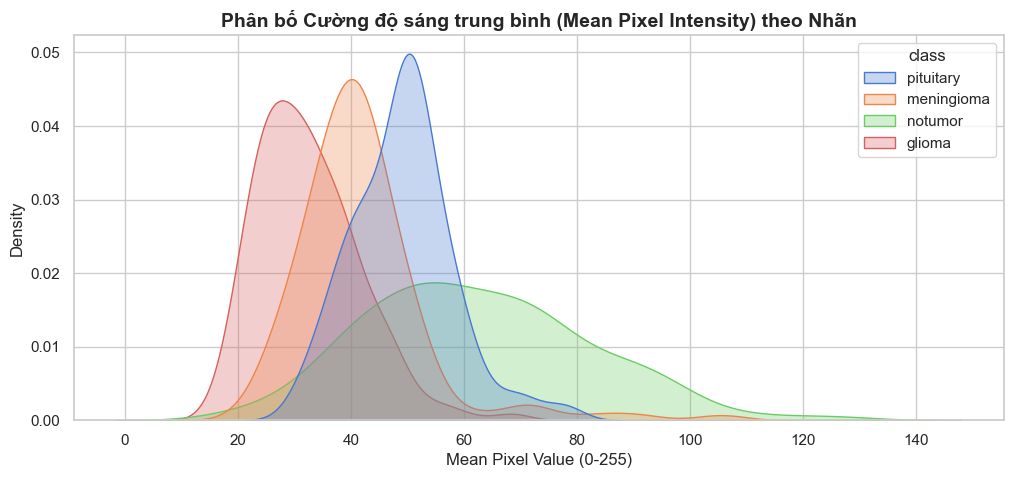

=> ĐỀ XUẤT TIỀN XỬ LÝ (PREPROCESSING RECOMMENDATION):
- Phân bố cường độ có sự khác biệt lớn giữa các ảnh (variance cao).
- Nên áp dụng kỹ thuật cân bằng Histogram như CLAHE (Contrast Limited Adaptive Histogram Equalization) hoặc Min-Max Normalization trên từng ảnh để đồng nhất độ sáng trước khi đưa vào mô hình Neural Network.


In [6]:
def compute_image_stats(filepath):
    try:
        img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
        return {
            'filepath': filepath,
            'mean_intensity': np.mean(img),
            'std_intensity': np.std(img),
            'max_intensity': np.max(img)
        }
    except:
        return None

# Lấy ngẫu nhiên 500 ảnh để phân tích chuyên sâu tránh tốn RAM
sample_df = df_meta.sample(min(500, len(df_meta)), random_state=42)

with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    intensity_stats = list(tqdm(executor.map(compute_image_stats, sample_df['filepath']), total=len(sample_df), desc='Computing Pixel Stats'))

intensity_stats = [x for x in intensity_stats if x is not None]
df_intensity = pd.DataFrame(intensity_stats)
sample_df = sample_df.merge(df_intensity, on='filepath')

plt.figure(figsize=(12, 5))
sns.kdeplot(data=sample_df, x='mean_intensity', hue='class', fill=True, common_norm=False, alpha=0.3)
plt.title('Phân bố Cường độ sáng trung bình (Mean Pixel Intensity) theo Nhãn')
plt.xlabel('Mean Pixel Value (0-255)')
plt.ylabel('Density')
plt.show()

print("=> ĐỀ XUẤT TIỀN XỬ LÝ (PREPROCESSING RECOMMENDATION):")
print("- Phân bố cường độ có sự khác biệt lớn giữa các ảnh (variance cao).")
print("- Nên áp dụng kỹ thuật cân bằng Histogram như CLAHE (Contrast Limited Adaptive Histogram Equalization) hoặc Min-Max Normalization trên từng ảnh để đồng nhất độ sáng trước khi đưa vào mô hình Neural Network.")


## 5. Trực quan hóa Mẫu (Sample Visualization)
Hiển thị một số ảnh cùng thông số để có cái nhìn trực quan.


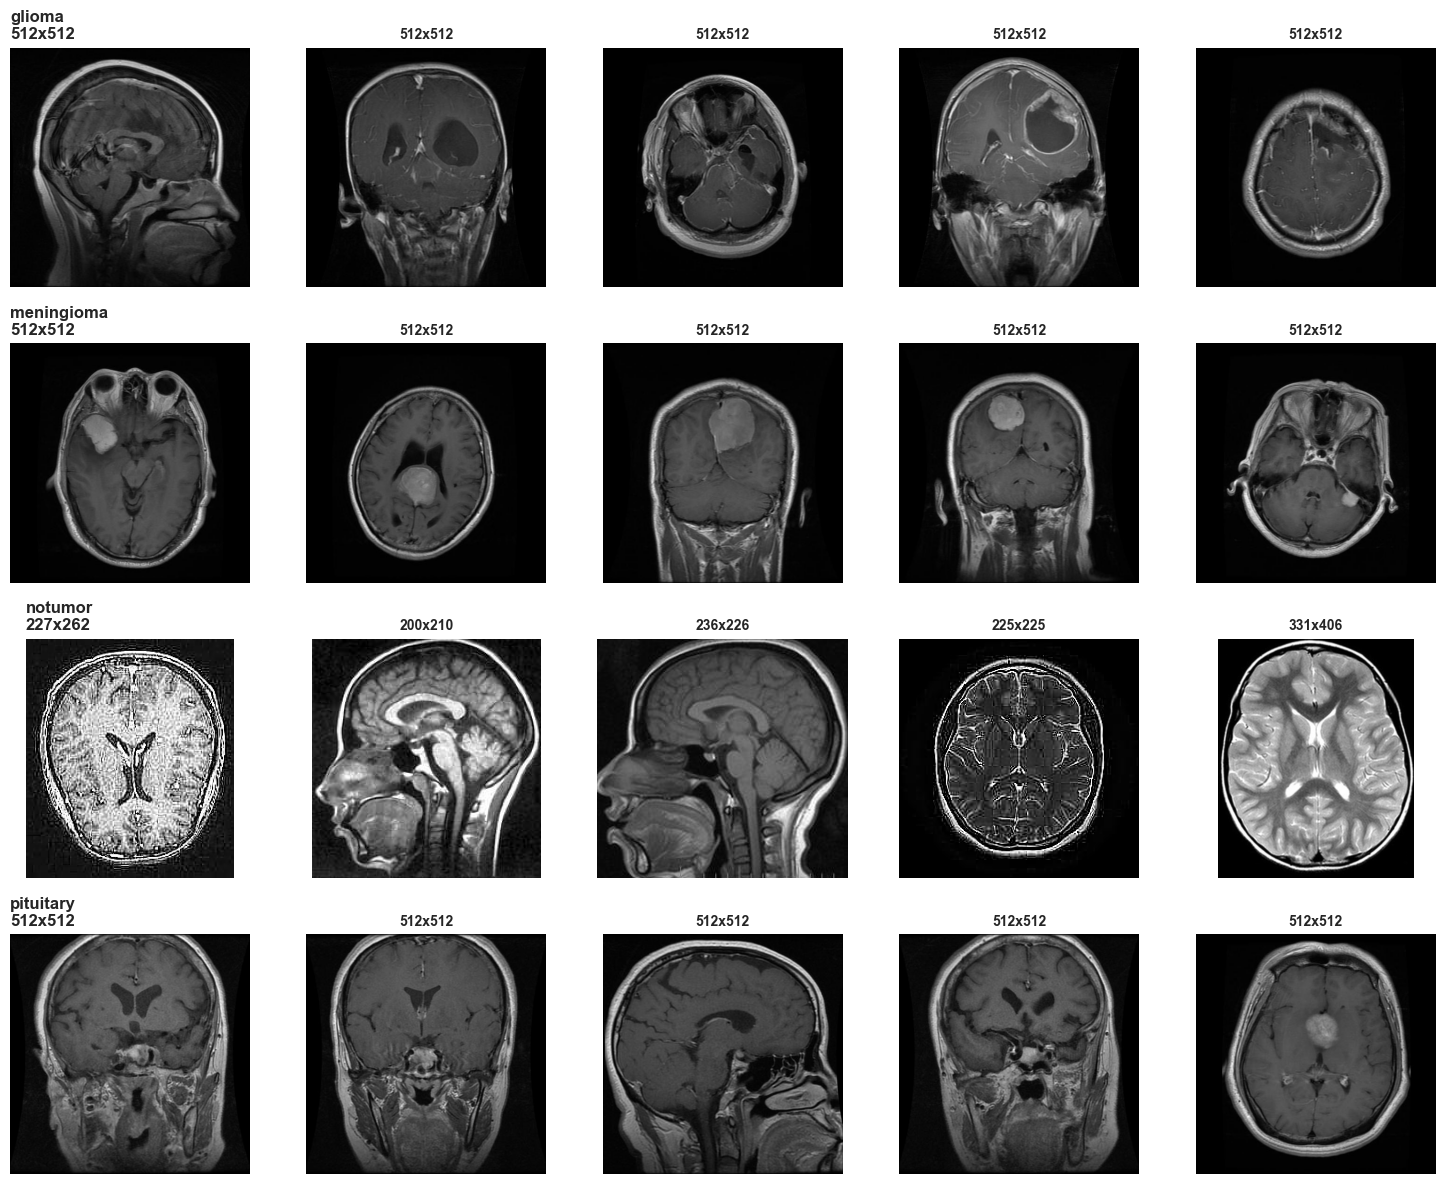

In [7]:
num_classes = len(CLASSES)
samples_per_class = 5

fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(15, 3 * num_classes))

for i, cls in enumerate(CLASSES):
    cls_samples = df_meta[df_meta['class'] == cls].sample(samples_per_class, random_state=42)
    for j, (_, row) in enumerate(cls_samples.iterrows()):
        img = cv2.imread(row['filepath'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(f"{cls}\n{row['width']}x{row['height']}", fontsize=12, fontweight='bold', loc='left')
        else:
            axes[i, j].set_title(f"{row['width']}x{row['height']}", fontsize=10)

plt.tight_layout()
plt.show()


## 6. Ảnh Trung Bình (Mean Image / Eigen-Brain)
Kỹ thuật tính trung bình toàn bộ ảnh của một lớp giúp chúng ta xem liệu mô hình có dễ dàng phát hiện ra vị trí điển hình của khối u bằng mắt thường qua sự chênh lệch ánh sáng hay không.


Mean Image glioma:   0%|          | 0/1400 [00:00<?, ?it/s]

Mean Image meningioma:   0%|          | 0/1400 [00:00<?, ?it/s]

Mean Image notumor:   0%|          | 0/1400 [00:00<?, ?it/s]

Mean Image pituitary:   0%|          | 0/1400 [00:00<?, ?it/s]

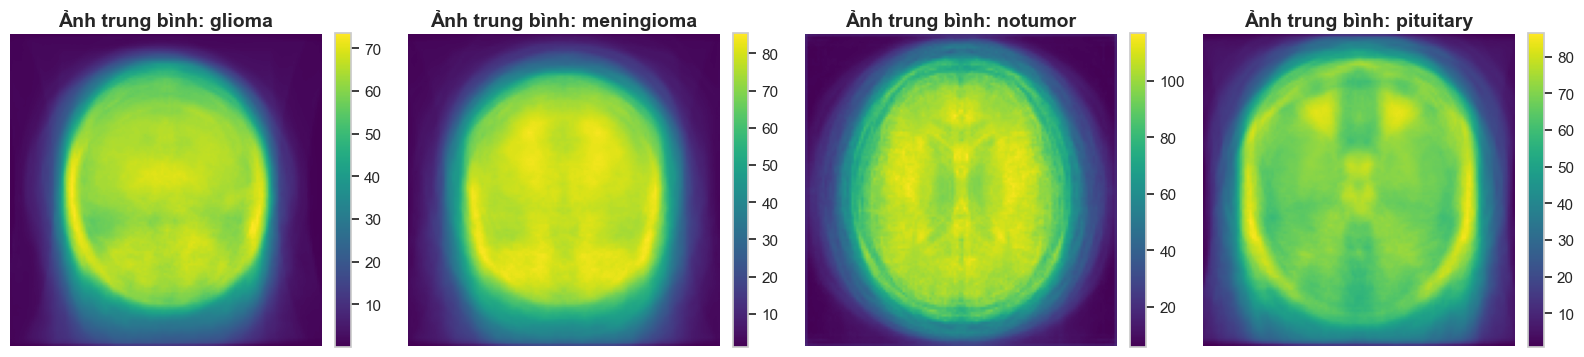

In [8]:
target_size = (128, 128)

def compute_mean_image(cls):
    cls_paths = df_meta[df_meta['class'] == cls]['filepath'].values
    mean_img = np.zeros((target_size[1], target_size[0]), np.float64)
    valid_count = 0
    
    for path in tqdm(cls_paths, desc=f"Mean Image {cls}", leave=False):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img_resized = cv2.resize(img, target_size)
            mean_img += img_resized
            valid_count += 1
            
    if valid_count > 0:
        mean_img /= valid_count
    return mean_img

fig, axes = plt.subplots(1, len(CLASSES), figsize=(16, 4))
mean_images = {}

for i, cls in enumerate(CLASSES):
    mean_img = compute_mean_image(cls)
    mean_images[cls] = mean_img
    
    im = axes[i].imshow(mean_img, cmap='viridis')
    axes[i].set_title(f"Ảnh trung bình: {cls}")
    axes[i].axis('off')
    fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## 7. Phát hiện bất thường (Outlier Detection)
Kiểm tra xem có ảnh nào cực nhỏ hoặc có tỷ lệ khung hình cực kỳ bất thường (ví dụ quá dẹt hoặc quá dài) không, vì chúng sẽ bị biến dạng nặng khi resize.


In [9]:
outliers = df_meta[(df_meta['aspect_ratio'] > 2.0) | (df_meta['aspect_ratio'] < 0.5) | (df_meta['width'] < 64) | (df_meta['height'] < 64)]
print(f"Phát hiện {len(outliers)} ảnh nghi ngờ là Outlier (Kích thước dị biệt):")
if len(outliers) > 0:
    display(outliers.head(10))
    print("=> Cần kiểm tra lại bằng tay các ảnh này, nếu chất lượng quá tệ nên loại bỏ khỏi tập Train.")
else:
    print("Không có Outlier dị biệt về kích thước.")


Phát hiện 0 ảnh nghi ngờ là Outlier (Kích thước dị biệt):
Không có Outlier dị biệt về kích thước.


## 8. Kết luận & Định hướng Pipeline Tiền xử lý

Dựa trên quá trình EDA chuyên sâu, chúng tôi thiết lập quy chuẩn cho Pipeline Tiền xử lý (Data Preprocessing Pipeline) như sau:

1. **Resize strategy:** Sử dụng `Resize Padding (Letterbox)` hoặc `Crop ở trung tâm` về `224x224` thay vì Resize ép buộc gây móp méo, vì aspect ratio tập trung quanh 1.0, nhưng có sự chênh lệch lớn về độ phân giải tuyệt đối.
2. **Xử lý Cường độ & Tương phản:** Áp dụng **CLAHE** để đồng bộ hóa độ tương phản hoặc Cắt bỏ viền đen (Cropping Brain Contours) để loại bỏ các pixel background vô dụng (giúp model tập trung vào não bộ thay vì background).
3. **Imbalance Handling:** (Dựa theo báo cáo phần 2). Nếu mất cân bằng trên 1.5, pipeline training phải wrap Dataset với Weighted Random Sampler (PyTorch) hoặc dùng Focal Loss.
4. **Data Augmentation:** Khuyến khích sử dụng các phép biến đổi: Horizontal Flip, Random Rotation (10-15 độ), Brightness/Contrast Shift để tăng tính robust cho mô hình.
